In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


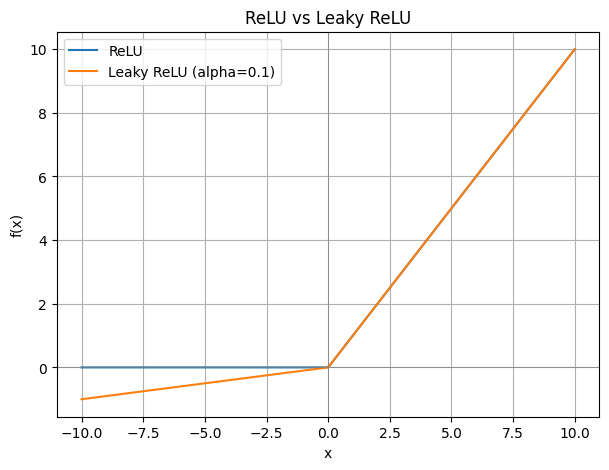

In [ ]:
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# Quick visualization of both functions
x = np.linspace(-10, 10, 200)
plt.figure(figsize=(7,5))
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, leaky_relu(x, alpha=0.1), label="Leaky ReLU (alpha=0.1)")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend()
plt.title("ReLU vs Leaky ReLU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode target for multi-class classification
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


In [ ]:
def build_model(activation="relu", alpha=0.01):
    if activation == "leaky_relu":
        model = keras.Sequential([
            layers.Input(shape=(4,)),
            layers.Dense(16),
            layers.LeakyReLU(negative_slope=alpha),
            layers.Dense(8),
            layers.LeakyReLU(negative_slope=alpha),
            layers.Dense(3, activation="softmax")
        ])
    else:  # standard relu
        model = keras.Sequential([
            layers.Input(shape=(4,)),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(3, activation="softmax")
        ])

    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
epochs = 100

model_relu = build_model("relu")
history_relu = model_relu.fit(X_train, y_train,
                               validation_data=(X_test, y_test),
                               epochs=epochs, verbose=0)

model_lrelu = build_model("leaky_relu", alpha=0.01)
history_lrelu = model_lrelu.fit(X_train, y_train,
                                 validation_data=(X_test, y_test),
                                 epochs=epochs, verbose=0)

print("ReLU  - Final val accuracy:", history_relu.history["val_accuracy"][-1])
print("LReLU - Final val accuracy:", history_lrelu.history["val_accuracy"][-1])

ReLU  - Final val accuracy: 1.0
LReLU - Final val accuracy: 1.0


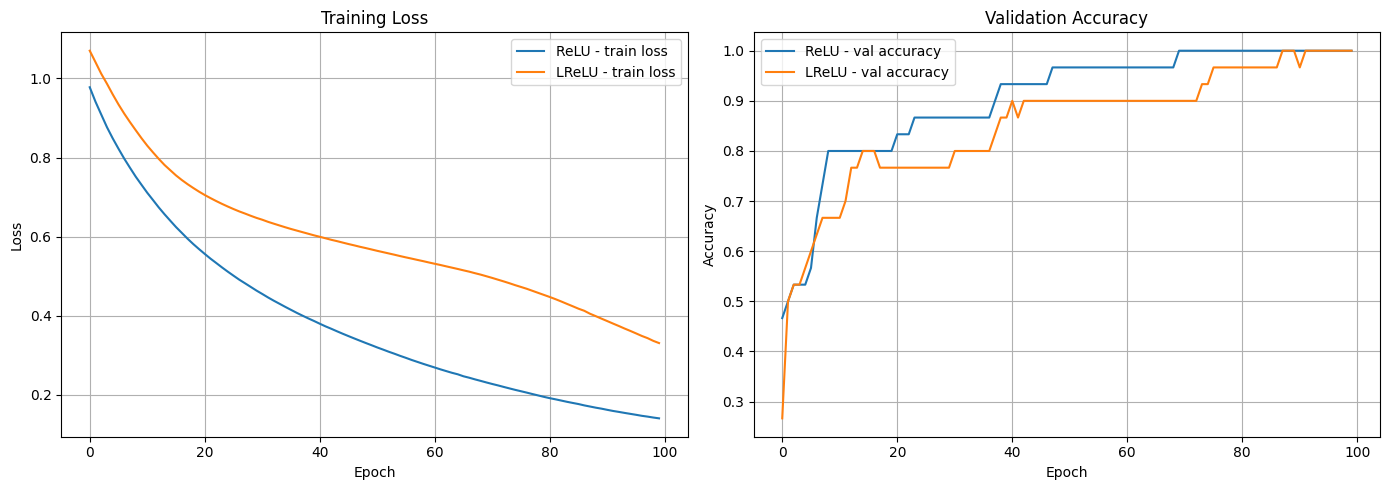

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_relu.history["loss"], label="ReLU - train loss")
axes[0].plot(history_lrelu.history["loss"], label="LReLU - train loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_relu.history["val_accuracy"], label="ReLU - val accuracy")
axes[1].plot(history_lrelu.history["val_accuracy"], label="LReLU - val accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_sizes = [0.1, 0.2, 0.3]
random_states = [0, 42, 100]

results = []

for ts in test_sizes:
    for rs in random_states:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_encoded, test_size=ts, random_state=rs
        )

        # ReLU model
        m_relu = build_model("relu")
        h_relu = m_relu.fit(X_train, y_train, validation_data=(X_test, y_test),
                             epochs=100, verbose=0)

        # Leaky ReLU model
        m_lrelu = build_model("leaky_relu", alpha=0.01)
        h_lrelu = m_lrelu.fit(X_train, y_train, validation_data=(X_test, y_test),
                               epochs=100, verbose=0)

        results.append({
            "test_size": ts,
            "random_state": rs,
            "ReLU_final_train_loss": h_relu.history["loss"][-1],
            "ReLU_final_val_acc": h_relu.history["val_accuracy"][-1],
            "LReLU_final_train_loss": h_lrelu.history["loss"][-1],
            "LReLU_final_val_acc": h_lrelu.history["val_accuracy"][-1],
        })

results_df = pd.DataFrame(results)
results_df

,test_size,random_state,ReLU_final_train_loss,ReLU_final_val_acc,LReLU_final_train_loss,LReLU_final_val_acc
0,0.1,0,0.137996,0.933333,0.149515,0.933333
1,0.1,42,0.170885,1.000000,0.116329,1.000000
2,0.1,100,0.360526,1.000000,0.176412,1.000000
3,0.2,0,0.208185,0.900000,0.168696,1.000000
4,0.2,42,0.201213,0.966667,0.176330,1.000000
5,0.2,100,0.171824,0.966667,0.213396,0.966667
6,0.3,0,0.244557,0.800000,0.151305,0.933333
7,0.3,42,0.299935,0.866667,0.177237,1.000000
8,0.3,100,0.499731,0.911111,0.178404,0.933333


           ReLU_final_val_acc  LReLU_final_val_acc
test_size                                         
0.1                  0.977778             0.977778
0.2                  0.944444             0.988889
0.3                  0.859259             0.955556


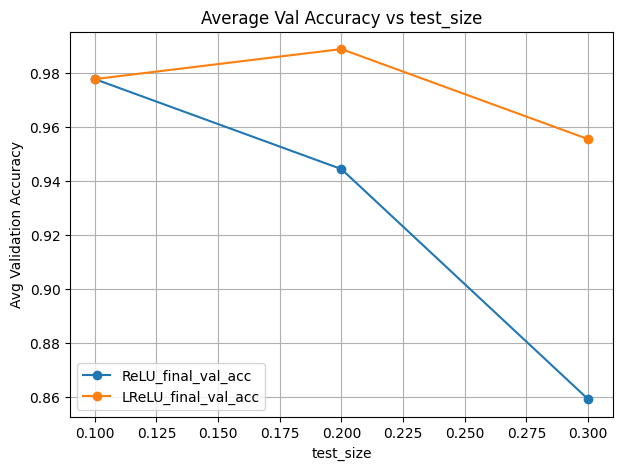

In [ ]:
avg_by_ts = results_df.groupby("test_size")[["ReLU_final_val_acc", "LReLU_final_val_acc"]].mean()
print(avg_by_ts)

avg_by_ts.plot(marker='o', figsize=(7,5))
plt.title("Average Val Accuracy vs test_size")
plt.ylabel("Avg Validation Accuracy")
plt.xlabel("test_size")
plt.grid(True)
plt.show()

What is Leaky ReLU?

Leaky ReLU (LReLU) is a modified version of the standard ReLU (Rectified Linear Unit) activation function used in neural networks. It was introduced to fix a specific weakness of ReLU called the "dying ReLU" problem.

Mathematically, Leaky ReLU is defined as:

𝑓(𝑥)={𝑥  if 𝑥>0
     {𝛼𝑥 if 𝑥≤0


Where α (alpha) is a small positive constant (commonly 0.01, sometimes 0.1), called the negative slope or leak factor.

In simple words: instead of completely blocking negative values (setting them to 0, like ReLU does), Leaky ReLU lets a small fraction of the negative value pass through.

Working Principle
For positive inputs (x > 0): Leaky ReLU behaves exactly like ReLU — it just passes the value through unchanged: f(x) = x.
For negative inputs (x ≤ 0): Instead of outputting 0, it outputs a small negative value: f(x) = α·x. For example, if α = 0.01 and x = -10, output = -0.1 (not 0).
Gradient behavior (this is the key point):
Standard ReLU's derivative is 0 for all x < 0 → during backpropagation, no gradient flows back through that neuron → its weights never get updated → the neuron is effectively "dead" forever.
Leaky ReLU's derivative is α (a small non-zero number) for x < 0 → a small gradient still flows back → the neuron's weights keep getting updated, even if small → the neuron has a chance to recover and become useful again later in training.

This is why it's called "leaky" — it leaks a small amount of gradient/signal through even when the neuron is technically "inactive."

The standard ReLU activation function is defined as f(x) = max(0, x), meaning it outputs the input value directly when it is positive, but outputs exactly zero for any negative input. Leaky ReLU, on the other hand, is defined as f(x) = x when x is greater than 0, and f(x) = αx when x is less than or equal to 0, where α is a small constant. This means that instead of completely blocking negative values like ReLU does, Leaky ReLU allows a small negative value (αx) to pass through.

This difference becomes especially important when looking at the gradient behavior during backpropagation. For negative inputs, ReLU's gradient is exactly 0, which means no learning happens for that neuron at that point — its weights simply stop updating. Leaky ReLU's gradient for negative inputs is α, a small but non-zero value, which means the neuron continues to receive some gradient signal and keeps learning even when its input is negative. As a direct consequence, ReLU is prone to the "dying neuron" problem, where a neuron can get permanently stuck outputting zero and never recovers, while Leaky ReLU largely avoids this issue since its neurons always retain a small chance to update and recover.

In terms of computation, ReLU is very cheap since it only involves a simple max operation, whereas Leaky ReLU is slightly more expensive because it requires an additional multiplication (αx) for negative inputs. Neither function adds extra trainable parameters to the network by default, since α is usually a fixed constant chosen beforehand — though it's worth noting that a related variant called PReLU (Parametric ReLU) treats α as a learnable parameter that the network optimizes during training.

When it comes to practical performance, ReLU tends to work well enough for simple or shallow networks trained on sufficient data, where dying neurons are less of a concern. Leaky ReLU tends to show more benefit in deeper networks, when using high learning rates, or when training data is limited — all situations where neurons are more likely to get pushed into negative territory permanently and stay "dead" under standard ReLU. Finally, there is a trade-off in sparsity: ReLU produces true sparse activations with many exact zeros, which can be computationally efficient, while Leaky ReLU produces less sparse outputs since its values are never exactly zero for negative inputs.

